In [297]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
from scipy.stats import bootstrap

# FILEPATH = '/scratch/nte5cp' 
FILEPATH = '/Users/a404/attention-brokers-bsky'
HANDLE = 'karaswisher.bsky.social'
DAYS_FWD = 14
DAYS_BWD = 14

TITLE = f'mean per-capita follow counts for {HANDLE}'

denoms = json.load(open(f'{FILEPATH}/population_counts/{HANDLE}_fwd_{DAYS_FWD}_bwd_{DAYS_BWD}.json', 'r'))
DENOM_FOL = denoms['ab_followers']
DENOM_NON = denoms['non_followers']
print(DENOM_NON, DENOM_FOL)

dfs = {}
for acct_type in ['control', 'did']:
    df = pd.read_csv(f'{FILEPATH}/interpolated_{acct_type}_csvs/{HANDLE}_fwd_{DAYS_FWD}_bwd_{DAYS_BWD}.csv')
    df_foll = df[df['ever_treated']]
    df_non = df[~df['ever_treated']]
    dfs[acct_type] = {}
    dfs[acct_type]['foll'] = df_foll
    dfs[acct_type]['non'] = df_non

3236751 298475


In [298]:
def plot_cis_and_means(df, color='red', label='AB_foll', denom=DENOM_FOL, hatch=None, alpha=0.1):
    """
    Given a dataframe of per-day per-reposted-account follow counts, 
    plot the mean and 95% bootstrapped CI of the per-day per-capita following rate.

    Inputs:
        df: dataframe with columns ts (in range(-14, 14)) and gain_rate
        color: color of the shaded CI + mean plot for this dataframe's data
        label: label of this dataset in the legend
        denom: denominator to calculate per-capita following rates.

    Outputs:
        Doesn't return anything; just plots the mean + CI.
    """
    ci_lows = []
    means = []
    ci_highs = []

    # for each day relative to repost, obtain the mean per-capita follower accumulation
    # as well as the 95% confidence interval on the mean.
    for ix in range(-1 * (DAYS_BWD), DAYS_FWD):
        gain_rate = df[df.ts == ix]['gain_rate'] / denom # normalize by population
        mean = gain_rate.mean()
        ci_low, ci_high = bootstrap(
            (np.array(gain_rate.to_list()),), 
            np.mean,
            confidence_level=0.95,
        ).confidence_interval
        ci_lows.append(ci_low)
        ci_highs.append(ci_high)
        means.append(mean)

    # fill in follower CI
    plt.fill_between(
        [i for i in range(-1 * (DAYS_BWD), DAYS_FWD)],
        ci_lows,
        ci_highs,
        color=color,
        alpha=alpha,
        hatch=hatch,
        label=label,
    )
    # plot mean on top of CI
    plt.plot(
        [i for i in range(-1 * (DAYS_BWD), DAYS_FWD)],
        means,
        color=color,
    )


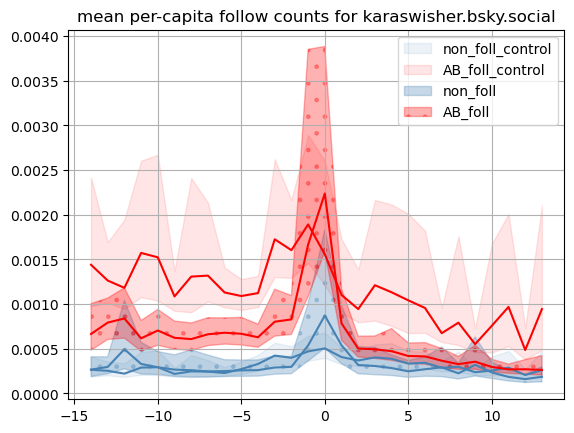

In [299]:
plot_cis_and_means(dfs['control']['non'], '#4682b4', 'non_foll_control', DENOM_NON, alpha=0.1)
plot_cis_and_means(dfs['control']['foll'], 'red', 'AB_foll_control', DENOM_FOL, alpha=0.1)
plot_cis_and_means(dfs['did']['non'], '#4682b4', 'non_foll', DENOM_NON, hatch='.', alpha=0.3)
plot_cis_and_means(dfs['did']['foll'], 'red', 'AB_foll', DENOM_FOL, hatch='.', alpha=0.3)
plt.legend()
plt.title(TITLE)
plt.grid()
plt.savefig(f'{FILEPATH}/plots/trends/{HANDLE}_unified_trends.png')

In [300]:
# make dataframe for DiD analysis; want 2 outcome variables -- one for followers and one for non-followers
# df_non['gain_rate'] = df_non['gain_rate'] / DENOM_NON
# df_foll['gain_rate'] = df_foll['gain_rate'] / DENOM_FOL

for acct_type in ['did', 'control']:
    df_non = dfs[acct_type]['non']
    df_foll = dfs[acct_type]['foll']
    df_non['gain_rate'] = df_non['gain_rate'] 
    df_foll['gain_rate'] = df_foll['gain_rate'] 

    df_wide = pd.merge(
        df_non, 
        df_foll, 
        left_on=['unit_id', 'ts'], 
        right_on=['unit_id', 'ts'], 
        suffixes=['_non', '_fol']
    )
    df_wide['period'] = df_wide['time_period_non']
    if acct_type == 'did':
        df_wide['post.treat'] = df_wide['ts'].apply(lambda b: b >= 0)
        df_wide['year_treated'] = df_wide['period'] - df_wide['ts']
    elif acct_type == 'control':
        df_wide['post.treat'] = 0
        df_wide['ts'] = 0
        df_wide['year_treated'] = 10000
    df_wide = df_wide[['period', 'post.treat', 'unit_id', 'gain_rate_fol', 'gain_rate_non', 'ts', 'year_treated']]
    df_wide.to_csv(f'{FILEPATH}/processed_{acct_type}_csvs/{HANDLE}_processed_did_data.csv')


/var/folders/8f/h3kcldy50kx99114fyyq93k00000gn/T/ipykernel_10715/2030125832.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_non['gain_rate'] = df_non['gain_rate']
/var/folders/8f/h3kcldy50kx99114fyyq93k00000gn/T/ipykernel_10715/2030125832.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_foll['gain_rate'] = df_foll['gain_rate']


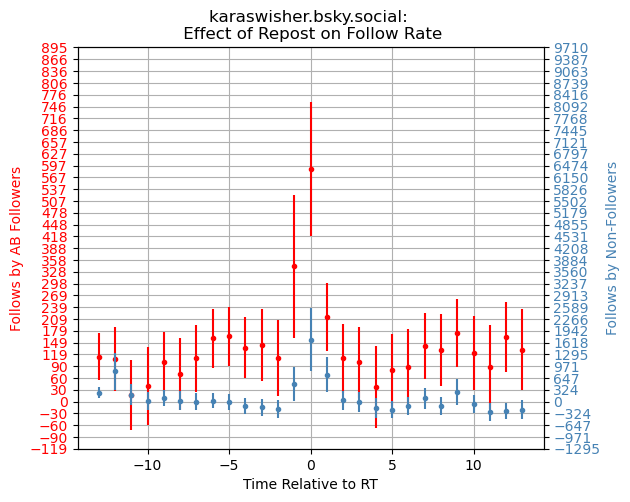

<Figure size 640x480 with 0 Axes>

In [304]:
FILEPATH = '/Users/a404/attention-brokers-bsky'
HANDLE = 'karaswisher.bsky.social'
DAYS_FWD = 14
DAYS_BWD = 14
MULT_LOW = -0.0004
MULT_HIGH = 0.003
twfe_fol = pd.read_csv(f'{FILEPATH}/r_out/{HANDLE}_twfe_fol.csv')
twfe_non = pd.read_csv(f'{FILEPATH}/r_out/{HANDLE}_twfe_non.csv')

denoms = json.load(open(f'{FILEPATH}/population_counts/{HANDLE}_fwd_{DAYS_FWD}_bwd_{DAYS_BWD}.json', 'r'))
DENOM_FOL = denoms['ab_followers']
DENOM_NON = denoms['non_followers']

fig, ax1 = plt.subplots()
color = 'red'
ax1.set_xlabel('Time Relative to RT')
ax1.set_ylabel('Follows by AB Followers', color=color)
ax1.errorbar(range(-13, 14), twfe_fol['estimate'], twfe_fol['std.error'], color=color, fmt='.')
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_ylim(MULT_LOW * DENOM_FOL, MULT_HIGH * DENOM_FOL)
ax1.set_yticks([0.0001 * DENOM_FOL * ix for ix in range(-4, 31)])
ax1.grid()
# ax1.set_yticks(
#     list(np.arange(MULT_LOW * DENOM_FOL, 0, 0.0001 * DENOM_FOL)) + \
#         list(np.arange(0, MULT_HIGH * DENOM_FOL, 0.0001 * DENOM_FOL)))
# ax1.grid()
ax2 = ax1.twinx()  # instantiate a second Axes that shares the same x-axis

color = '#4682b4'
ax2.set_ylabel('Follows by Non-Followers', color=color)  # we already handled the x-label with ax1
ax2.errorbar(range(-13, 14), twfe_non['estimate'], twfe_non['std.error'], color=color, fmt='.')
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(MULT_LOW * DENOM_NON, MULT_HIGH * DENOM_NON)
ax2.set_yticks([0.0001 * DENOM_NON * ix for ix in range(-4, 31)])
# ax1.set_yticks(
#     list(np.arange(MULT_LOW * DENOM_NON, 0, 0.0001 * DENOM_NON)) + \
#         list(np.arange(0, MULT_HIGH * DENOM_NON, 0.0001 * DENOM_NON)))
# ax2.grid()
fig.tight_layout()  # otherwise the right y-label is slightly clipped
plt.title(f'{HANDLE}: \n Effect of Repost on Follow Rate')
plt.show()
plt.savefig(f'{FILEPATH}/plots/event_studies_mixed_axes/{HANDLE}.pdf')

In [192]:
twfe_non

,Unnamed: 0,term,estimate,std.error,statistic,p.value
0,1,ts::-13:treat,0.135190,12.556250,0.010767,0.991410
1,2,ts::-12:treat,-2.250729,14.660202,-0.153526,0.877988
2,3,ts::-11:treat,3.542068,21.654371,0.163573,0.870073
3,4,ts::-10:treat,30.109928,31.483511,0.956371,0.338923
4,5,ts::-9:treat,0.595483,20.181667,0.029506,0.976462
5,6,ts::-8:treat,-1.477276,21.926019,-0.067375,0.946285
6,7,ts::-7:treat,11.548244,24.947253,0.462906,0.643448
7,8,ts::-6:treat,3.834394,27.003178,0.141998,0.887086
8,9,ts::-5:treat,2.058232,31.838121,0.064647,0.948457
9,10,ts::-4:treat,17.706761,29.871940,0.592756,0.553367
